# Did New York's billed revenue grow from Q2 to Q3, and did more claims or bigger claims carry it?

**Week 3, Build 1, Wednesday: the parallel build on one metro.** Kalpa Health is a US
diagnostics business, fictional and synthetic in every record. It runs a laboratory and two
patient service centres, where patients have blood drawn, in each of six US metro areas, and its
revenue-cycle and analytics work runs from Kalpa's Global Capability Centre (GCC) in Bengaluru,
where you work as trainee engineers in the data and AI team. A booking is one patient's visit to
have tests done, and a completed booking is billed as one claim: a bill at Kalpa Health's list
prices sent to the payer, whoever pays for the patient's tests, which is a commercial health
plan, Medicare (the federal programme for people aged 65 and over), Medicaid (each state's
programme for people on low incomes) or the patient. Today the word also names something else:
each group's headline claim, the one sentence it states at the day's close, so this notebook
says headline claim for the sentence and claim for the bill. The quarters are calendar Q2 (April
to June 2026) and Q3 (July to September 2026), and every file is the export taken on Friday 16
October 2026.

> **The client asks.** "My dashboard says test volumes grew 5 percent from Q2 to Q3. The plan
> the board approved asks for 18. Which branch of my business is short, and what do I do next?"
>
> Dr Priya Menon, chief operating officer, Kalpa Health

Each of the five questions Dr Menon's heads have asked needs the same moves before it has a
headline claim: say what one row is, convert every amount, reconcile one file against another, and only
then split the number. This notebook runs those moves once, end to end, on a question smaller
than any group's: New York's billed revenue, one metro of six. The metric at stake is **billed
revenue**, the dollars on the claims at list prices, which splits into two leaves: how many
claims were billed, and the mean claim, the average dollars on one claim. Quest Diagnostics, a
US laboratory company, states its own growth the way this notebook ends, with the period and
both bases on the same page (section 8).

**Who needs the answer.** The finance head, who writes the board's page on where the plan's
growth went and reads each metro's billed revenue as claims times the mean claim. A metro whose
growth is misread by a few points can be the one Dr Menon decides to fix, and the recovery effort
then goes to a place that was never short.

**The questions on the way.**
1. How could a team find what moved New York's billed revenue, and what does each way cost?
2. How many New York bookings does the old booking export hold?
3. Does every New York amount convert to dollars, and what does the quickest conversion do to the total?
4. Do the claims and the completed bookings describe the same visits, one to one?
5. Did more claims or a bigger mean claim carry the change, and does it hold per day?
6. Which New York site billed the extra claims, and where does this build stop?
7. Does SQL, run on the same raw files, reach the same claims and dollars?
8. What sentence can the finance head carry, with its denominators, its period and its caveat?

**Setup.** The next cell finds the shared helper `kit` by walking up from this folder, then reads
two of the ten Kalpa Health files from Monday's data folder, `../../D1/data/`: the old booking
system's export and the billing system's claims. Every value is read as text, so nothing is
converted before it has been looked at, and the cell keeps each file's New York rows.
`quarter()` reads Q2 or Q3 from an ISO date, one written year, month and day, such as
2026-07-01, and `usd()` prints dollars the way a US price list does.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import pandas as pd

DATA = pathlib.Path("../../D1/data")
raw_bookings = pd.read_csv(DATA / "C2_W03_D01_bookings_legacy_STUDENT.csv", dtype=str, keep_default_na=False)
raw_claims = pd.read_csv(DATA / "C2_W03_D01_claims_STUDENT.csv", dtype=str, keep_default_na=False)

# The slice: New York only. A group profiles its whole file; this build profiles the rows it uses.
bookings = raw_bookings[raw_bookings["metro"] == "New York"].copy()
claims = raw_claims[raw_claims["metro"] == "New York"].copy()

def quarter(dates):
    """Q2 is April to June and Q3 is July to September, read from the ISO date text."""
    return dates.map(lambda d: "Q2" if d < "2026-07-01" else "Q3")

def usd(value, cents=False):
    """Dollars with a thousands comma and, where asked, the cents."""
    v = float(value)
    text = f"${abs(v):,.2f}" if cents else f"${abs(round(v)):,}"
    return "-" + text if v < 0 else text

bookings["quarter"] = quarter(bookings["booking_date"])
claims["quarter"] = quarter(claims["service_date"])
print(f"New York rows read: {len(bookings):,} from the old booking export, {len(claims):,} from the claims")

New York rows read: 2,128 from the old booking export, 2,032 from the claims


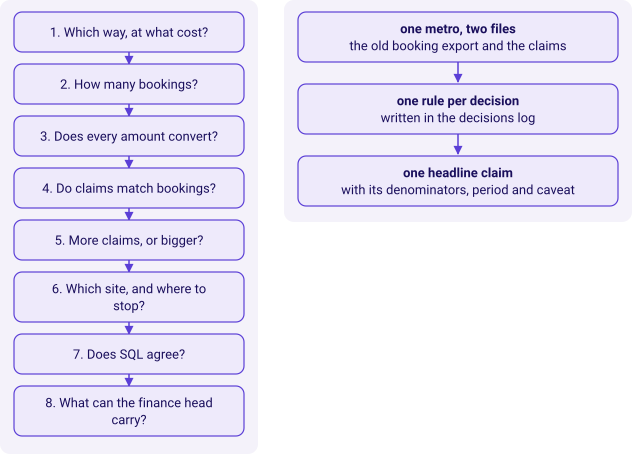

In [2]:
kit.side_by_side(
    kit.ladder(["Which way, at what cost?", "How many bookings?", "Does every amount convert?",
                "Do claims match bookings?", "More claims, or bigger?", "Which site, and where to stop?",
                "Does SQL agree?", "What can the finance head carry?"], lit=None, show=False),
    kit.vflow(["one metro, two files\nthe old booking export and the claims",
               "one rule per decision\nwritten in the decisions log",
               "one headline claim\nwith its denominators, period and caveat"], show=False),
)

## 1. How could a team find what moved New York's billed revenue, and what does each way cost?

Billed revenue is what Kalpa Health asked the payers for, at list prices. At Kalpa Retail an
order's amount was what the shopper paid at the till; at Kalpa Health the payers pay a contracted
share of a claim weeks later, so billed revenue measures what Kalpa Health asked for, and the
money that arrives is a smaller number that answers a different decision. The domain dossier, `content/W03/D1/study-notes/C2_W03_D01_domain_us_healthcare_STUDENT.md`,
follows one claim from the list price to the cash in its section 3, for more depth. The finance
head's question is what moved the billed number, and four ways could answer it.

| Option | What the team does | Rows it reads | What it can say | What it assumes |
|---|---|---|---|---|
| A. Compare the totals | Sums each quarter's billed dollars on the claims | The claims | Whether billed revenue grew, and by how many dollars | Every amount is a number |
| B. The tree on the claims alone | Splits each quarter into claims times the mean claim | The claims | Whether more claims or bigger claims carried the change | Each claim is one completed booking, and each completed booking has one claim |
| C. The tree after reconciling | Keeps one row per booking, proves the claims match the completed bookings one to one, then splits | The booking export and the claims | The same split, plus a count of visits the finance head's analyst can audit | One booking id is one booking |
| D. The tree on the booking export | Takes the export's rows as the volume and divides billed dollars by them | The booking export, and the claims' totals | A volume and the billed dollars per booking | Every row is one completed, billed booking |

**Predict before you run.** Which of the options will report different growth in volume on the
same New York files? a) B and C, since C reads a second file; b) B and D, since D counts the
export's rows; c) none, since the three that report a volume read the same two quarters; d) all
three that report a volume, since each reads different rows.

Option,Rows read,Volume growth it reports,What it would miss,"Hours for a group, estimated"
A. Compare the totals,"2,032","none, totals only",Which leaf moved,about 0.2
B. The tree on the claims alone,"2,032","+8.0%, claims","A claim that is not a visit, or a visit never billed",about 0.3
C. The tree after reconciling,"4,160","B's figure, once proved or disproved",Nothing these two files can show,about 1
D. The tree on the booking export,"4,160","+4.8%, export rows","Any row that is not one completed, billed booking",about 0.3


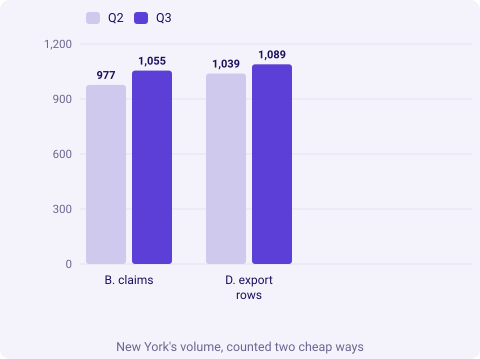

In [3]:
import time

start = time.perf_counter()
claims_q = claims.groupby("quarter").size()
rows_q = bookings.groupby("quarter").size()
seconds = time.perf_counter() - start
grow = lambda s: s["Q3"] / s["Q2"] - 1
kit.table(["Option", "Rows read", "Volume growth it reports", "What it would miss", "Hours for a group, estimated"],
          [["A. Compare the totals", f"{len(claims):,}", "none, totals only", "Which leaf moved", "about 0.2"],
           ["B. The tree on the claims alone", f"{len(claims):,}", f"{grow(claims_q):+.1%}, claims",
            "A claim that is not a visit, or a visit never billed", "about 0.3"],
           ["C. The tree after reconciling", f"{len(bookings) + len(claims):,}", "B's figure, once proved or disproved",
            "Nothing these two files can show", "about 1"],
           ["D. The tree on the booking export", f"{len(bookings) + len(claims):,}", f"{grow(rows_q):+.1%}, export rows",
            "Any row that is not one completed, billed booking", "about 0.3"]],
          caption=f"The four options, sized on New York's files as exported; both counts ran in {seconds:.3f} seconds")
kit.columns(["B. claims", "D. export rows"], [("Q2", [claims_q["Q2"], rows_q["Q2"]]), ("Q3", [claims_q["Q3"], rows_q["Q3"]])],
            title="New York's volume, counted two cheap ways", width=480)

**What happened.** The answer is b. On the same quarters, the claims grow 8.0 percent and the
export's rows 4.8 percent, so the two cheap ways disagree by more than three points before
anyone has asked why. Option A cannot see the split at all. Every option runs in under a second
on these rows, so what separates them is an analyst's hour and what each would miss.

**The best-fit call** is C, because only a reconciliation can say which of B's and D's counts is
New York's volume. It reads both files, 2,128 more rows than B, and costs about 0.7 of an hour
more than B, against a number the finance head will put on the board's page. This is Week 1
Tuesday's first rung, confirm the number before explaining it, since two cheap counts that
disagree confirm nothing. D is out: it reads as many rows as C and assumes every row is one
completed, billed booking, which is exactly what C tests. **What would switch it.** A control
total from Dr Menon's data team, a signed count of what a file should hold, saying the claims
file holds one claim per completed booking and nothing else, would make B enough and save the
hour.

## 2. How many New York bookings does the old booking export hold?

Week 1 Wednesday's first move is the profile: what one row is, how many there are and what each
column holds, before anything is cleaned. The data dictionary says one row of this export is one
booking, and the export holds 2,128 New York rows.

**Predict before you run.** How many New York bookings does the old export hold? a) exactly
2,128, since the data dictionary says one row is one booking; b) fewer than 2,128, if any
booking id appears on more than one row; c) more than 2,128, if some rows hold two bookings
each; d) no way to tell until the claims are read, since only a claim proves a booking happened.

In [4]:
def profile(df, columns):
    """Per column: filled, blank, distinct values, and one example, which is the Week 1 profile."""
    rows = []
    for c in columns:
        filled = (df[c] != "").sum()
        rows.append([c, f"{filled:,}", f"{len(df) - filled:,}", f"{df[c].nunique():,}", df[c].iloc[0]])
    return rows

kit.table(["Column", "Filled", "Blank", "Distinct", "Example"],
          profile(bookings, ["booking_id", "patient_id", "site_code", "booking_date", "channel", "status", "updated_at"]),
          caption=f"The old booking export, New York rows: {len(bookings):,}")
kit.table(["Column", "Filled", "Blank", "Distinct", "Example"],
          profile(claims, ["claim_id", "booking_id", "service_date", "billed_amount"]),
          caption=f"The claims, New York rows: {len(claims):,}. The tree reads these four columns.")
distinct_ids = bookings["booking_id"].nunique()
kit.check("the export holds more rows than distinct booking ids", len(bookings) > distinct_ids,
          f"{len(bookings):,} rows, {distinct_ids:,} distinct ids")
kit.check("every claim id appears once", claims["claim_id"].is_unique, f"{len(claims):,} claims")
rows_q = bookings.groupby("quarter").size()
ids_q = bookings.groupby("quarter")["booking_id"].nunique()
wrong, right = rows_q["Q3"] / rows_q["Q2"] - 1, ids_q["Q3"] / ids_q["Q2"] - 1
kit.table(["Count", "Q2", "Q3", "Change"],
          [["Rows in the export (the plausible wrong answer)", f"{rows_q['Q2']:,}", f"{rows_q['Q3']:,}", f"{wrong:+.1%}"],
           ["Distinct booking ids", f"{ids_q['Q2']:,}", f"{ids_q['Q3']:,}", f"{right:+.1%}"],
           ["Extra rows", f"{rows_q['Q2'] - ids_q['Q2']}", f"{rows_q['Q3'] - ids_q['Q3']}", ""]],
          caption="New York, the old booking export, counted two ways")
kit.check("rows and bookings disagree on New York's growth", round(wrong, 3) != round(right, 3),
          f"{wrong:+.1%} on rows, {right:+.1%} on bookings")

Column,Filled,Blank,Distinct,Example
booking_id,"2,128",0,"2,095",KB0002971
patient_id,"2,128",0,952,P-003269
site_code,"2,128",0,3,KH-NYC-02
booking_date,"2,128",0,183,2026-05-18
channel,"2,085",43,5,walk-in
status,"2,128",0,2,completed
updated_at,"2,128",0,"2,080",2026-05-18 19:17


Column,Filled,Blank,Distinct,Example
claim_id,"2,032",0,"2,032",KH-CLM-000033
booking_id,"2,032",0,"2,032",KB0000033
service_date,"2,032",0,183,2026-04-01
billed_amount,"2,032",0,85,180


Count,Q2,Q3,Change
Rows in the export (the plausible wrong answer),"1,039","1,089",+4.8%
Distinct booking ids,"1,013","1,082",+6.8%
Extra rows,26,7,


**What happened.** The answer is b. The export holds 2,128 New York rows and 2,095 distinct
`booking_id` values, so 33 ids appear on two rows each. The claims pass the same test: 2,032
rows and 2,032 distinct claim ids. `channel`, how the patient booked, is blank on 43 rows; this
tree splits by site, so the column is logged as not used and left as it is. The billed amounts
were read as text, which section 3 deals with.

**The plausible wrong answer.** Count rows per quarter and call them bookings, as the last table
does. New York then grows from 1,039 to 1,089, a rise of 4.8 percent, the number a hurried
analyst would send.

**Why it is wrong.** The repeated ids are not spread evenly: 26 of the 33 extra rows sit in Q2
and 7 in Q3, so counting rows swells the base quarter and makes New York look slower than it was.
A metro reported at 4.8 percent when its bookings grew 6.8 percent could be the one Dr Menon
decides to fix. The check that catches it is the one above, rows against distinct ids, per
quarter, before any rate is written.

**The fix: one rule for what makes a booking.** One `booking_id` is one booking, the Week 1
Wednesday identity rule. Where two rows share an id, keep the row with the later `updated_at`,
the system's latest word on the booking. Of the 33 pairs, 26 are identical in every field and 7
differ only in `updated_at`, so the rule loses no fact about any booking. Why a booking id
appears on two rows is a question for Dr Menon's data team; it goes into the challenges log, the
group's dated record of every obstacle and open question, as a question, and the rule does not
wait for the answer.

In [5]:
pairs = bookings[bookings["booking_id"].duplicated(keep=False)].groupby("booking_id")
identical = sum(1 for _, g in pairs if len(g.drop_duplicates()) == 1)
only_updated = sum(1 for _, g in pairs
                   if len(g.drop_duplicates()) == 2 and len(g.drop(columns=["updated_at"]).drop_duplicates()) == 1)
clean = bookings.sort_values(["booking_id", "updated_at"]).drop_duplicates("booking_id", keep="last")
set_aside = len(bookings) - len(clean)
kit.table(["Repeated ids", "Identical in every field", "Differ only in updated_at", "Rows set aside"],
          [[f"{pairs.ngroups}", f"{identical}", f"{only_updated}", f"{set_aside}"]],
          caption="What the identity rule decided")
kit.check("rows read equal rows kept plus rows set aside", len(bookings) == len(clean) + set_aside,
          f"{len(bookings):,} = {len(clean):,} + {set_aside}")
kit.check("every repeated pair differs, if at all, only in updated_at", identical + only_updated == pairs.ngroups,
          f"{identical} + {only_updated}")
kit.check("the kept rows hold one row per booking id", clean["booking_id"].is_unique)

Repeated ids,Identical in every field,Differ only in updated_at,Rows set aside
33,26,7,33


## 3. Does every New York amount convert to dollars, and what does the quickest conversion do to the total?

Revenue can only be summed once every amount is a number. The `billed_amount` column was read as
text, and the quickest conversion, the one many analysts reach for, is
`pd.to_numeric(..., errors="coerce")`. Week 1
Wednesday's rule for an amount that cannot be read was to reject it with its row named and to
repair it only from a source that could not have copied the error.

**Predict before you run.** What does the coerced sum do to New York's billed revenue? a) it
stops with an error at the first amount it cannot read; b) it matches the true total to the
dollar, since coerce only changes the type; c) it comes out too high, since a text amount is
read twice; d) it comes out short, and nothing on the screen says so.

In [6]:
coerced = pd.to_numeric(claims["billed_amount"], errors="coerce")
dropped = claims[coerced.isna()]
wrong_total = coerced.groupby(claims["quarter"]).sum()
kit.table(["What the coerced sum shows", "Q2", "Q3", "Growth"],
          [["Billed revenue (the plausible wrong answer)", usd(wrong_total["Q2"]), usd(wrong_total["Q3"]),
            f"{wrong_total['Q3'] / wrong_total['Q2'] - 1:+.1%}"],
           ["Amounts turned into blanks", f"{(dropped['quarter'] == 'Q2').sum()}", f"{(dropped['quarter'] == 'Q3').sum()}", ""]],
          caption="New York's claims, coerced")
print("The amounts coerce could not read:", ", ".join(dropped["billed_amount"]))

What the coerced sum shows,Q2,Q3,Growth
Billed revenue (the plausible wrong answer),"$174,242","$184,250",+5.7%
Amounts turned into blanks,5,1,


The amounts coerce could not read: $170.00, $149.00, $60.00, $140.00, $149.00, $235.00


**What happened.** The answer is d. Six amounts are written as text with a dollar sign and
cents, the way a spreadsheet prints currency, and coerce turned each into a blank without a
message: five in Q2 and one in Q3. The Q2 total comes out $668 short and Q3 $235 short, and on
those totals New York's billed revenue grows 5.7 percent.

**Why it is wrong.** Nothing on the screen says anything was lost. The finance head would report
New York growing 5.7 percent where every amount, converted, gives 5.5, and the books and this
notebook would disagree by $903 with no row to point at, so the board's page would carry a
growth rate nobody can reconcile. The check that catches it counts the amounts that failed to
convert, which must be zero before any total is read. **The fix.** Remove the dollar sign
and any comma, then convert strictly, so an amount still unreadable stops the run with its row
named instead of vanishing.

In [7]:
claims["amount_usd"] = (claims["billed_amount"].str.replace("$", "", regex=False)
                        .str.replace(",", "", regex=False).astype(float))
right_total = claims.groupby("quarter")["amount_usd"].sum()
kit.table(["Billed revenue", "Q2", "Q3", "Growth"],
          [["Coerced (wrong)", usd(wrong_total["Q2"]), usd(wrong_total["Q3"]), f"{wrong_total['Q3'] / wrong_total['Q2'] - 1:+.1%}"],
           ["Every amount converted", usd(right_total["Q2"]), usd(right_total["Q3"]), f"{right_total['Q3'] / right_total['Q2'] - 1:+.1%}"],
           ["What the blanks hid", usd(right_total["Q2"] - wrong_total["Q2"]), usd(right_total["Q3"] - wrong_total["Q3"]), ""]],
          caption="New York's claims, the same rows summed two ways")
kit.check("no amount is left unconverted", claims["amount_usd"].notna().all(), f"{len(claims):,} amounts")
kit.check("the fix recovers exactly what coerce dropped",
          round(right_total.sum() - wrong_total.sum(), 2) == round(claims.loc[dropped.index, "amount_usd"].sum(), 2),
          usd(right_total.sum() - wrong_total.sum()))

Billed revenue,Q2,Q3,Growth
Coerced (wrong),"$174,242","$184,250",+5.7%
Every amount converted,"$174,910","$184,485",+5.5%
What the blanks hid,$668,$235,


## 4. Do the claims and the completed bookings describe the same visits, one to one?

A booking ends completed or cancelled, and only a completed one is billed. If the two files
describe the same visits, every completed booking has exactly one claim and no cancelled booking
has one. Week 2 Tuesday's rule is that a join is counted before anything is summed, because a
join can repeat rows it matches twice and the sum moves without a warning. A hurried analyst
joins the raw export to the claims on `booking_id` and sums the amounts.

**Predict before you run.** Joined on `booking_id` to the raw export, how many rows come back?
a) 2,032, one per claim; b) 2,128, one per export row; c) more than 2,032 and fewer than 2,128;
d) fewer than 2,032, since cancelled rows fall away.

In [8]:
fanned = bookings.merge(claims, on="booking_id", suffixes=("", "_clm"))
fanned_q = fanned.groupby("quarter_clm")["amount_usd"].sum()
kit.table(["Joined on the raw export", "Rows", "Q2 billed", "Q3 billed", "Growth"],
          [["The plausible wrong answer", f"{len(fanned):,}", usd(fanned_q["Q2"]), usd(fanned_q["Q3"]),
            f"{fanned_q['Q3'] / fanned_q['Q2'] - 1:+.1%}"],
           ["The claims themselves", f"{len(claims):,}", usd(right_total["Q2"]), usd(right_total["Q3"]),
            f"{right_total['Q3'] / right_total['Q2'] - 1:+.1%}"]],
          caption="The same claims, joined to the export before the identity rule")
from pandas.errors import MergeError
try:
    bookings.merge(claims, on="booking_id", validate="one_to_one")
    refused = None
except MergeError as error:
    refused = str(error).splitlines()[0]
print("MergeError:", refused)
kit.check("a join that declares its grain refuses the raw export", refused is not None, refused)

Joined on the raw export,Rows,Q2 billed,Q3 billed,Growth
The plausible wrong answer,"2,065","$179,499","$185,354",+3.3%
The claims themselves,"2,032","$174,910","$184,485",+5.5%


MergeError: Merge keys are not unique in left dataset; not a one-to-one merge


**What happened.** The answer is c: 2,065 rows. Every repeated booking that was completed carries
its claim twice, so the joined billed revenue reads $364,853 against $359,395 in the claims,
$5,458 too much, $4,589 of it in Q2. New York's growth then reads 3.3 percent instead of 5.5.

**Why it is wrong.** The join changed the grain, what one row stands for, from one row per claim
to one row per export row without saying so, which is the Week 2 fan-out. The check that catches
it is `validate="one_to_one"`, Week 2 Thursday's answer to "Which argument stops the merge?",
which refuses the join the moment either side repeats a key, as it did here. **The fix.** Join the kept rows, with the grain declared, and
keep both sides visible with an outer join, so a booking with no claim and a claim with no
booking would each show up instead of vanishing. Then write the reconciliation as Week 1
Wednesday's arithmetic: rows read equal rows kept plus rows set aside, all the way down to the
claims.

Step,Rows
Rows read from the old export,"2,128"
Set aside by the identity rule,33
Bookings kept,"2,095"
"of which cancelled, so no claim is expected",63
of which completed,"2,032"
Completed bookings matched to one claim,"2,032"
Claims with no booking in the export,0
Cancelled bookings with a claim,0


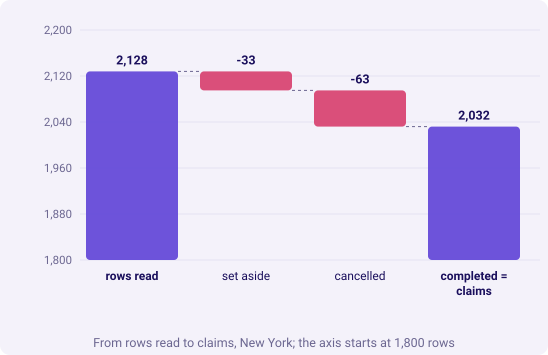

In [9]:
joined = clean.merge(claims, on="booking_id", how="outer", validate="one_to_one",
                     suffixes=("", "_clm"), indicator=True)
side = joined["_merge"].value_counts()
completed = clean[clean["status"] == "completed"]
cancelled = clean[clean["status"] == "cancelled"]
matched = joined[joined["_merge"] == "both"]
kit.table(["Step", "Rows"],
          [["Rows read from the old export", f"{len(bookings):,}"],
           ["Set aside by the identity rule", f"{set_aside}"],
           ["Bookings kept", f"{len(clean):,}"],
           ["of which cancelled, so no claim is expected", f"{len(cancelled)}"],
           ["of which completed", f"{len(completed):,}"],
           ["Completed bookings matched to one claim", f"{(matched['status'] == 'completed').sum():,}"],
           ["Claims with no booking in the export", f"{side.get('right_only', 0)}"],
           ["Cancelled bookings with a claim", f"{(matched['status'] == 'cancelled').sum()}"]],
          caption="New York, Q2 and Q3 together")
kit.bridge(("rows read", len(bookings)), [("set aside", -set_aside), ("cancelled", -len(cancelled))],
           end_label="completed = claims", fmt=lambda v: f"{v:,.0f}", lo=1800,
           title="From rows read to claims, New York; the axis starts at 1,800 rows")
kit.check("rows read equal kept plus set aside", len(bookings) == len(clean) + set_aside)
kit.check("every completed booking has exactly one claim",
          (matched["status"] == "completed").sum() == len(completed) == len(claims),
          f"{len(completed):,} completed, {len(claims):,} claims")
kit.check("no claim lacks a booking, and no cancelled booking is billed",
          side.get("right_only", 0) == 0 and (matched["status"] == "cancelled").sum() == 0)

## 5. Did more claims or a bigger mean claim carry the change, and does it hold per day?

Week 1 Monday's revenue tree splits a total into branches that multiply back to it, each a count
over a denominator. For a lab's billed revenue the first split is claims times the mean claim,
where the mean claim is billed dollars over claims: the claim count stands where Week 1's order
count stood, and the mean claim where the average order value stood. Sections 2 to 4 proved that
the claims are New York's completed bookings, one to one, so the claim count is a count of
visits.

**Predict before you run.** Which leaf moved New York's billed revenue from Q2 to Q3? a) more
claims, at a lower mean claim; b) more claims, at the same mean claim; c) more claims, at a
higher mean claim; d) more claims, with the mean claim unknown until a claim's lines are opened.

Leaf,Q2,Q3,Change
Billed revenue,"$174,910","$184,485",+5.5%
Claims (completed bookings),977,"1,055",+8.0%
Mean claim,$179.03,$174.87,-2.3%
Median claim,$150,$150,+0.0%


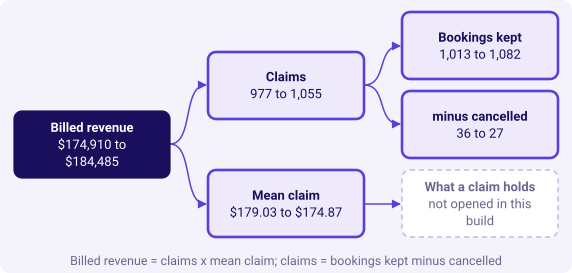

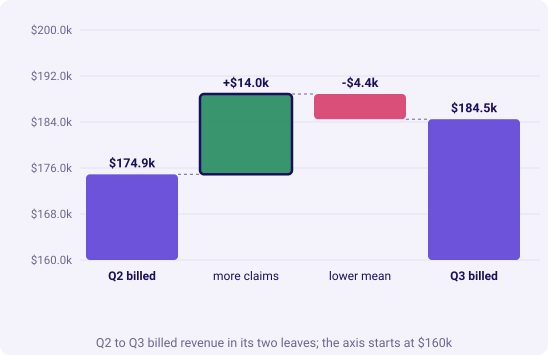

In [10]:
tree = claims.groupby("quarter")["amount_usd"].agg(["count", "sum", "mean", "median"])
q2, q3 = tree.loc["Q2"], tree.loc["Q3"]
kept_q = clean.groupby("quarter").size()
cancel_q = cancelled.groupby("quarter").size()
move = lambda a, b: f"{b / a - 1:+.1%}"
kit.table(["Leaf", "Q2", "Q3", "Change"],
          [["Billed revenue", usd(q2["sum"]), usd(q3["sum"]), move(q2["sum"], q3["sum"])],
           ["Claims (completed bookings)", f"{int(q2['count']):,}", f"{int(q3['count']):,}", move(q2["count"], q3["count"])],
           ["Mean claim", usd(q2["mean"], cents=True), usd(q3["mean"], cents=True), move(q2["mean"], q3["mean"])],
           ["Median claim", usd(q2["median"]), usd(q3["median"]), move(q2["median"], q3["median"])]],
          caption="New York, from the claims, after sections 2 to 4")
kit.driver_tree({"label": "Billed revenue", "note": f"{usd(q2['sum'])} to {usd(q3['sum'])}", "kind": "lit",
                 "children": [
                     {"label": "Claims", "note": f"{int(q2['count']):,} to {int(q3['count']):,}", "kind": "known",
                      "children": [{"label": "Bookings kept", "note": f"{kept_q['Q2']:,} to {kept_q['Q3']:,}", "kind": "known"},
                                   {"label": "minus cancelled", "note": f"{cancel_q['Q2']} to {cancel_q['Q3']}", "kind": "known"}]},
                     {"label": "Mean claim", "note": f"{usd(q2['mean'], cents=True)} to {usd(q3['mean'], cents=True)}",
                      "kind": "known",
                      "children": [{"label": "What a claim holds", "note": "not opened in this build", "kind": "unknown"}]}]},
                title="Billed revenue = claims x mean claim; claims = bookings kept minus cancelled")
volume = (q3["count"] - q2["count"]) * q2["mean"]
value = q3["count"] * (q3["mean"] - q2["mean"])
kit.bridge(("Q2 billed", q2["sum"]), [("more claims", round(volume)), ("lower mean", round(value))],
           end_label="Q3 billed", lit=[0], lo=160000,
           fmt=lambda v: ("-" if v < 0 else "") + f"${abs(v) / 1000:,.1f}k",
           title="Q2 to Q3 billed revenue in its two leaves; the axis starts at $160k")
kit.check("the two leaves add up to the change in billed revenue", round(volume + value) == round(q3["sum"] - q2["sum"]),
          f"{usd(volume)} and {usd(value)}")
kit.check("more claims and a lower mean, as predicted", q3["count"] > q2["count"] and q3["mean"] < q2["mean"])

**What happened.** The answer is a. Claims rose 8.0 percent, from 977 to 1,055, and the mean
claim fell 2.3 percent, from $179.03 to $174.87, so billed revenue rose 5.5 percent, from
$174,910 to $184,485: billed revenue grew more slowly than the claims, so the mean claim had to
fall. The bridge, a chart that walks from one total to another in steps, splits the $9,575 into
its two leaves in tree order: the 78 extra claims at Q2's mean add $13,964, and Q3's lower mean
across all 1,055 claims takes away $4,389. The median claim stayed at $150, so the mean moved
without a typical claim changing.

**A total, or a pace?** Q2 runs 91 days, April to June, and Q3 runs 92, July to September.

**Predict before you run.** Per day, how much did New York's claims grow from Q2 to Q3? a) 8.0
percent, the same as the totals; b) about 5.6 percent; c) about 6.8 percent; d) about 9.2
percent.

In [11]:
days = {"Q2": 91, "Q3": 92}
per_day = {q: (tree.loc[q, "count"] / days[q], tree.loc[q, "sum"] / days[q]) for q in days}
kit.table(["Per day", "Q2, 91 days", "Q3, 92 days", "Change"],
          [["Claims", f"{per_day['Q2'][0]:.2f}", f"{per_day['Q3'][0]:.2f}", move(per_day["Q2"][0], per_day["Q3"][0])],
           ["Billed revenue", usd(per_day["Q2"][1]), usd(per_day["Q3"][1]), move(per_day["Q2"][1], per_day["Q3"][1])]],
          caption="New York, the same totals over unequal quarters")
kit.check("the two quarters are different lengths, so totals are not a pace", days["Q2"] != days["Q3"], "91 and 92 days")
kit.check("New York bills claims on every calendar day of both quarters, so calendar days are the base",
          claims["service_date"].nunique() == days["Q2"] + days["Q3"], f"{claims['service_date'].nunique()} distinct days")
kit.check("per day, claims grow more slowly than the totals say",
          per_day["Q3"][0] / per_day["Q2"][0] < q3["count"] / q2["count"])
slip = lambda d2, d3: (tree.loc["Q3", "count"] / d3) / (tree.loc["Q2", "count"] / d2) - 1
print(f"Counting Q2 as 90 days gives {slip(90, 92):+.1%}; swapping the two lengths gives {slip(92, 91):+.1%}.")

Per day,"Q2, 91 days","Q3, 92 days",Change
Claims,10.74,11.47,+6.8%
Billed revenue,"$1,922","$2,005",+4.3%


Counting Q2 as 90 days gives +5.6%; swapping the two lengths gives +9.2%.


**What happened.** The answer is c. Per day, claims rose 6.8 percent and billed revenue 4.3
percent, about 1.2 points below the totals. New York bills claims on all 183 calendar days of
the two quarters, so dividing by calendar days is fair here. Counting Q2 as 90 days gives 5.6
percent, and swapping the two lengths gives 9.2.

**The plausible wrong answer.** "New York billed 8.0 percent more claims in Q3." It is true of
the totals and wrong as a pace, since one extra day of work sits inside it. **Why it is
wrong.** A pace read from totals credits New York with a point of growth the calendar gave it,
so a finance head who sets it against a plan written per month or per day reads New York as
running faster than it did. Week 1 Tuesday's like-with-like rung asks for the same weeks, or a
rate per day, before any change is read. **The fix.** Quote the per-day change beside the
totals, or quote the totals with the window lengths in the same sentence.

## 6. Which New York site billed the extra claims, and where does this build stop?

New York has three sites: KH-NYC-01, its laboratory, and two patient service centres, KH-NYC-02
and KH-NYC-03. This is Week 1 Tuesday's isolate rung:
once the tree has split the change into its leaves, find where it sits. Splitting the claims by
site says where inside New York the extra claims were billed, which is a question about place;
it cannot say why the mean claim fell.

**Predict before you run.** Split by site, will the three sites' claims add back to New York's
977 and 1,055? a) yes, exactly, since every kept booking names one site; b) no, short by the 63
cancelled bookings; c) no, over by the laboratory's claims, which are counted twice; d) no,
short by the 33 rows the identity rule set aside.

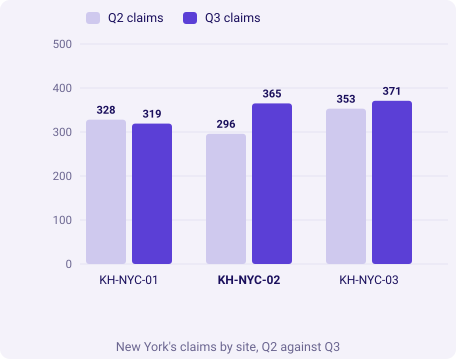

Site,Q2 claims,Q3 claims,Change,Q2 billed,Q3 billed
KH-NYC-01,328,319,-9,"$57,526","$55,765"
KH-NYC-02,296,365,+69,"$52,840","$65,271"
KH-NYC-03,353,371,+18,"$64,544","$63,449"


In [12]:
by_site = (clean.merge(claims, on="booking_id", validate="one_to_one", suffixes=("", "_clm"))
                .groupby(["site_code", "quarter_clm"])["amount_usd"].agg(["count", "sum"]))
sites = sorted(clean["site_code"].unique())
kit.columns(sites, [("Q2 claims", [by_site.loc[(c, "Q2"), "count"] for c in sites]),
                    ("Q3 claims", [by_site.loc[(c, "Q3"), "count"] for c in sites])], lit=[1],
            title="New York's claims by site, Q2 against Q3")
kit.table(["Site", "Q2 claims", "Q3 claims", "Change", "Q2 billed", "Q3 billed"],
          [[c, f"{by_site.loc[(c, 'Q2'), 'count']:,}", f"{by_site.loc[(c, 'Q3'), 'count']:,}",
            f"{by_site.loc[(c, 'Q3'), 'count'] - by_site.loc[(c, 'Q2'), 'count']:+,}",
            usd(by_site.loc[(c, "Q2"), "sum"]), usd(by_site.loc[(c, "Q3"), "sum"])] for c in sites],
          caption="New York by site, from the kept bookings joined to their claims")
kit.check("the sites add back to the metro, in claims and dollars",
          by_site["count"].sum() == len(claims) and round(by_site["sum"].sum(), 2) == round(claims["amount_usd"].sum(), 2),
          f"{by_site['count'].sum():,} claims, {usd(by_site['sum'].sum())}")

**What happened.** The answer is a: the three sites add back to 977 and 1,055 claims and to
every dollar, since each claim's booking names one site. KH-NYC-02 billed 69 more claims, 296 to
365, KH-NYC-03 billed 18 more, and the laboratory, KH-NYC-01, billed 9 fewer, so one patient
service centre carried most of New York's growth in volume. **Where this build stops.** Below the mean claim sits what each claim
holds, and why the mean fell is a question the claims alone cannot answer. It goes into the
challenges log as an open question for the branch below, which this build does not open.

## 7. Does SQL, run on the same raw files, reach the same claims and dollars?

A second route earns its place only if it could fail where the first route is wrong. This one
runs the whole build again in SQL, in SQLite, a database engine that ships inside Python, so the
query runs with no server. It loads the two raw files itself with Python's `csv` module, keeps
New York and works out each quarter from the month in SQL, keeps one row per booking with Week 2
Wednesday's `ROW_NUMBER()`, partitioned by booking id and kept at 1, makes Week 2 Tuesday's join
on the kept rows, and builds Week 2 Monday's tree as one `GROUP BY`. It shares none of the pandas
cells' logic, only the data folder's path and the table helper. SQLite's `CAST` reads only the leading number in a text and drops the rest
without a word, so "$170.00" would become 0, the same silence as coerce; the query strips the
dollar sign and any comma before the cast, and a check counts any amount in the file still
holding something other than digits and a point.

In [13]:
import csv
import sqlite3

# The raw files, loaded as text by the csv module: nothing from the pandas cells is reused.
con = sqlite3.connect(":memory:")
for table, name in [("bookings", "C2_W03_D01_bookings_legacy_STUDENT.csv"), ("claims", "C2_W03_D01_claims_STUDENT.csv")]:
    with open(DATA / name, newline="", encoding="utf-8") as f:
        rows = list(csv.reader(f))
    columns = ", ".join(c + " TEXT" for c in rows[0])
    con.execute(f"CREATE TABLE {table} ({columns})")
    con.executemany(f"INSERT INTO {table} VALUES ({', '.join('?' * len(rows[0]))})", rows[1:])
query = """
WITH ranked AS (
  SELECT *, ROW_NUMBER() OVER (PARTITION BY booking_id ORDER BY updated_at DESC) AS n
  FROM bookings WHERE metro = 'New York'),
kept AS (SELECT * FROM ranked WHERE n = 1 AND status = 'completed')
SELECT CASE WHEN CAST(substr(c.service_date, 6, 2) AS INTEGER) BETWEEN 4 AND 6 THEN 'Q2'
            WHEN CAST(substr(c.service_date, 6, 2) AS INTEGER) BETWEEN 7 AND 9 THEN 'Q3' END AS quarter,
       COUNT(*) AS claims,
       ROUND(SUM(CAST(REPLACE(REPLACE(c.billed_amount, '$', ''), ',', '') AS REAL)), 2) AS billed
FROM kept JOIN claims c ON c.booking_id = kept.booking_id
GROUP BY quarter ORDER BY quarter"""
sql_tree = {quarter: (n, billed) for quarter, n, billed in con.execute(query)}
unreadable = con.execute("""SELECT COUNT(*) FROM claims
    WHERE REPLACE(REPLACE(REPLACE(billed_amount, '$', ''), ',', ''), '.', '') GLOB '*[^0-9]*'
       OR billed_amount = ''""").fetchone()[0]
kit.table(["Route", "Q2 claims", "Q3 claims", "Q2 billed", "Q3 billed"],
          [["pandas, sections 2 to 5", f"{int(q2['count']):,}", f"{int(q3['count']):,}", usd(q2["sum"]), usd(q3["sum"])],
           ["SQL in SQLite, from the raw files", f"{sql_tree['Q2'][0]:,}", f"{sql_tree['Q3'][0]:,}",
            usd(sql_tree["Q2"][1]), usd(sql_tree["Q3"][1])]],
          caption="Two routes, each reading the raw files with its own code")
kit.check("no amount in the claims file reaches the SQL cast still holding text", unreadable == 0, f"{unreadable} unreadable")
kit.check("SQL and pandas agree on the claims in each quarter",
          [sql_tree["Q2"][0], sql_tree["Q3"][0]] == [int(q2["count"]), int(q3["count"])])
kit.check("SQL and pandas agree on billed revenue to the cent",
          [round(sql_tree["Q2"][1], 2), round(sql_tree["Q3"][1], 2)] == [round(q2["sum"], 2), round(q3["sum"], 2)])

Route,Q2 claims,Q3 claims,Q2 billed,Q3 billed
"pandas, sections 2 to 5",977,"1,055","$174,910","$184,485"
"SQL in SQLite, from the raw files",977,"1,055","$174,910","$184,485"


**What happened.** Both routes land on 977 and 1,055 claims and on $174,910 and $184,485, to the
cent. The SQL route read the files, kept New York, chose the kept row, converted the amounts and
gave each claim its quarter with its own code, so a slicing, period, parsing or summing error in
the pandas cells would have shown here as a gap. It cannot catch an error in a rule both routes
share on purpose: one booking id is one booking, the latest `updated_at` wins, and a claim
belongs to the quarter of its service date. **When to switch.** On the warehouse in Week 2 the SQL route was the first route, since
Finance's number belongs where Finance can rerun it; on two CSV files and an hour of build time,
pandas leads and SQL checks.

## 8. What sentence can the finance head carry, with its denominators, its period and its caveat?

Week 1 Thursday's note runs claim, evidence, caveat, action, claim first, because a reader with
two minutes reads the first line and stops. The headline claim carries its number, its
denominators (the claims in each quarter), its period (Q2's 91 days against Q3's 92) and the
branch that carried the change; the caveat goes on its own line below and is never folded into
the claim.

| Part | New York, Q2 against Q3 |
|---|---|
| **Headline claim** | Over Q2's 91 days and Q3's 92, New York's billed revenue rose 5.5 percent, from $174,910 on 977 claims to $184,485 on 1,055 claims, carried by 78 more claims at a mean claim $4.16 lower. |
| **Evidence** | The old export's 2,128 New York rows are 2,095 bookings under one identity rule; the 2,032 completed bookings match the 2,032 claims one to one; every amount converts; SQL on the raw files reaches the same claims and dollars; the bridge splits the $9,575 into $13,964 from more claims and minus $4,389 from the lower mean; per day, billed revenue rose 4.3 percent. |
| **Caveat** | Billed revenue is list price, and the payers pay a contracted share of it weeks later, so the money collected may have grown by more or less than 5.5 percent. |
| **Action** | Report New York as growing on claim volume, and open the branch below the mean claim to learn why it fell before anyone calls the lower mean a price or a mix change. |

A listed lab writes growth the same way. Quest Diagnostics' annual report for 2025 gives net
revenues of $11,035 million against $9,872 million for 2024 and says they "increased by 11.8%
compared to the prior year", with the period and both bases on the page. Its next sentence does
the work of a caveat line: "organic growth was 5.3% compared to the prior year", the growth that
did not come from its recent acquisitions. Its revenue is an estimate that includes "the impact
of contractual allowances (including payer denials), and patient price concessions", so what a
US lab reports as revenue is what it expects to collect, below its list-price charges, and that
is why New York's headline claim says billed.

The decisions log has one row per decision, in the columns of the log every group opened on
Monday: Week 1 Wednesday's rule, the rows it moved and its reason, with the field and the issue
added. It includes a row that was kept as it was.

Field,Issue,Rows,Decision,Reason
booking_id,33 ids appear on two rows,33,Keep the row with the later updated_at,"One id is one booking; 26 pairs are identical and 7 differ only in updated_at, so no booking fact is lost"
billed_amount,6 amounts written as text with a dollar sign,6,"Remove the dollar sign and any comma, convert strictly",Coerce would blank them and leave billed revenue $903 short with no error
channel,Blank on 43 rows,43,Kept as they are,"This tree splits by site, so the blanks change no number here; logged for any split by channel"
status,63 cancelled bookings carry no claim,63,"Kept, outside billed revenue",A cancelled booking is a real booking that bills nothing; the reconciliation shows each one


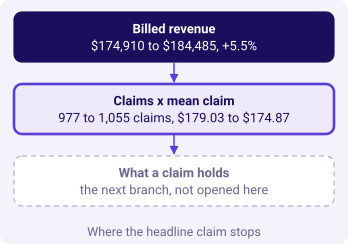

In [14]:
kit.table(["Field", "Issue", "Rows", "Decision", "Reason"],
          [["booking_id", "33 ids appear on two rows", "33", "Keep the row with the later updated_at",
            "One id is one booking; 26 pairs are identical and 7 differ only in updated_at, so no booking fact is lost"],
           ["billed_amount", "6 amounts written as text with a dollar sign", "6", "Remove the dollar sign and any comma, convert strictly",
            "Coerce would blank them and leave billed revenue $903 short with no error"],
           ["channel", "Blank on 43 rows", "43", "Kept as they are",
            "This tree splits by site, so the blanks change no number here; logged for any split by channel"],
           ["status", "63 cancelled bookings carry no claim", "63", "Kept, outside billed revenue",
            "A cancelled booking is a real booking that bills nothing; the reconciliation shows each one"]],
          caption="The decisions log for the New York build")
kit.vflow([f"Billed revenue\n{usd(q2['sum'])} to {usd(q3['sum'])}, +5.5%",
           f"Claims x mean claim\n977 to 1,055 claims, {usd(q2['mean'], cents=True)} to {usd(q3['mean'], cents=True)}",
           "What a claim holds\nthe next branch, not opened here"],
          kinds=["lit", "known", "unknown"], title="Where the headline claim stops")

Kavya Nair, the senior analyst on the team at the GCC, checks every number before it leaves the
team.

> **Kavya's review.** "I want the count you started from, every row you set aside with its
> reason, and a second way to the same total. You have 2,128 rows read, 33 set aside and 63
> cancelled, and SQL lands on the same 2,032 claims and $359,395. Now tell me why the mean fell
> before anyone calls it price."

### In the interview: how do you reconcile two systems' ids, and how do you say a finding in one sentence?

**[F] Two systems export the same entity with different id formats; how do you reconcile them?**
"I profile both keys before any join: the formats each system writes and how many rows carry
each, because a format I have not counted is one my rule will miss. Then I write one rule that
maps every format to one canonical key and apply it to both sides, leaving both exports
untouched. I prove the rule on the rows: the match count before and after, an anti-join in both
directions, and every leftover classified as a real gap or a defect in the rule. On the way I
check the grain, so a key repeated on one side cannot double a total, and the rule goes in the
decisions log so the finance team can rerun it. When no rule maps one format to the other, I ask
the owner of one system for a crosswalk, a table that maps its ids to the other's, and I report
the share still unmatched beside every number I give. The profile also catches keys that look
alike and belong to different populations: Kalpa Retail's campaign platform keyed its August
list C-6000 to C-6159 while Finance's order file keyed its customers C-2000 to C-5003, so no row
could match, and the profile showed it before any join was trusted."
Here the booking system and the billing system happened to write `booking_id` the same way, and
the proof was the same: one to one, both directions, every leftover named.

**[D] State your finding in one sentence a COO can carry into a board meeting.** "Over Q2's 91
days and Q3's 92, New York's billed revenue rose 5.5 percent, from about $174,900 on 977 claims
to about $184,500 on 1,055, carried by more claims at a slightly lower mean claim." Then the
caveat, alone on the next line: billed is not collected, since the payers pay a contracted share
weeks later. The number, both bases, the period and the branch that carried it sit in one
sentence, rounded the way a board reads them with the exact figures in the evidence, and nothing
in it needs a chart to be understood.

### Depth: does the bridge's split depend on which leaf moves first?

It does. In tree order, the volume leaf is priced at
Q2's mean and the mean leaf is counted on Q3's claims: $13,964 and minus $4,389. Reversed, the
extra 78 claims are priced at Q3's lower mean, $13,640, and the mean's fall is counted on Q2's
977 claims, minus $4,065. Both orders add to $9,575, and the $324.51 between them is the joint
part, the 78 extra claims times the $4.16 fall in the mean, the change that exists only because
both leaves moved at once. The symmetric split gives each leaf half of it: $13,802 and minus
$4,227. Week 1 Tuesday chose the tree order and stated it, since a report that does not state
its order leaves $324.51 of the split unexplained.

In [15]:
d_claims, d_mean = q3["count"] - q2["count"], q3["mean"] - q2["mean"]
orders = [["Tree order: volume at Q2's mean, mean on Q3's claims", usd(d_claims * q2["mean"]), usd(q3["count"] * d_mean)],
          ["Reversed: volume at Q3's mean, mean on Q2's claims", usd(d_claims * q3["mean"]), usd(q2["count"] * d_mean)],
          ["Symmetric: each leaf takes half the joint part", usd(d_claims * (q2["mean"] + q3["mean"]) / 2),
           usd(d_mean * (q2["count"] + q3["count"]) / 2)]]
kit.table(["Order", "More claims", "Lower mean"], orders, caption="New York's $9,575, split three ways")
joint = d_claims * d_mean
print(f"The joint part: {d_claims:.0f} extra claims times {usd(d_mean, cents=True)} = {usd(joint, cents=True)}")
kit.check("every order adds back to the change in billed revenue",
          all(round(a + b, 2) == round(q3["sum"] - q2["sum"], 2) for a, b in
              [(d_claims * q2["mean"], q3["count"] * d_mean), (d_claims * q3["mean"], q2["count"] * d_mean)]))

Order,More claims,Lower mean
"Tree order: volume at Q2's mean, mean on Q3's claims","$13,964","-$4,389"
"Reversed: volume at Q3's mean, mean on Q2's claims","$13,640","-$4,065"
Symmetric: each leaf takes half the joint part,"$13,802","-$4,227"


The joint part: 78 extra claims times -$4.16 = -$324.51


## So did New York's billed revenue grow from Q2 to Q3, and did more claims or bigger claims carry it?

1. Option C, the tree after reconciling, because the claims (up 8.0 percent) and the export's
   rows (up 4.8 percent) disagree and only a reconciliation can say which counts New York's
   volume; option C reads both files, 4,160 rows, against option B's 2,032 claims, for about
   0.7 of an hour more.
2. The export holds 2,095 bookings in 2,128 rows: 33 ids appear twice, 26 of the extra rows in
   Q2, so bookings grew 6.8 percent where rows grew 4.8.
3. Six amounts were dollar text, and coerce left billed revenue $903 short, $668 in Q2 and $235
   in Q3, so growth read 5.7 percent against 5.5; removing the dollar sign and converting
   strictly recovers every dollar.
4. Yes: 2,095 bookings are 2,032 completed and 63 cancelled, and the 2,032 completed match
   2,032 claims one to one; the raw join fans out to 2,065 rows and $5,458 too much.
5. More claims at a lower mean: claims up 8.0 percent and the mean claim down 2.3 percent, so
   $13,964 more from volume and $4,389 less from the mean; per day, over 91 and 92 days, claims
   rose 6.8 percent and billed revenue 4.3.
6. The three sites add back to every claim and dollar; KH-NYC-02, a patient service centre,
   billed 69 of the extra claims, and the build stops at what a claim holds, with why the mean
   fell logged as an open question.
7. Yes: SQL in SQLite reaches 977 and 1,055 claims and $174,910 and $184,485, to the cent.
8. "Over Q2's 91 days and Q3's 92, New York's billed revenue rose 5.5 percent, from $174,910 on
   977 claims to $184,485 on 1,055 claims, carried by 78 more claims at a mean claim $4.16
   lower", with the caveat on its own line: billed is not collected, so the money collected may
   have grown by more or less.

New York's billed revenue grew 5.5 percent, $9,575, and more claims carried it: 78 more claims
added $13,964 while a mean claim $4.16 lower took $4,389 away.

In [16]:
kit.check_summary()
print("Next: your group's own question, run through the same moves, with its headline claim ready for the close.")

Next: your group's own question, run through the same moves, with its headline claim ready for the close.
